# Thrivot - Income-Aware Affordability Model

This is a standalone notebook for the **second** model: an affordability classifier that
reasons about a user's income as an explicit input.

The first notebook (`affordability_xgboost.ipynb`) builds the **cost-of-living regression**
model and saves it as `model_cost.pkl`. That model was fine. The weakness was the original
affordability classifier: it saw only ONE income per city (the area median) and that same
column also built the label, so it never learned how affordability changes as *income* changes.

**The fix here:**
1. Replicate every city across many sampled household incomes ($1,800-$16,000/mo).
2. Label each copy by whether that specific income covers that city's real cost of living.
3. Add `user_income_monthly` as an explicit feature so income is an independent variable
   the model must reason about.
4. City-grouped split, then prove it learned by sweeping income for one city and watching the
   affordability score rise and cross 50% at the city's true cost.

## 1. Imports

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBRegressor, XGBClassifier

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110
print("Libraries loaded.")

Libraries loaded.


## 2. Load data & rebuild the unified cost target

Same preparation as the first notebook: fuse MIT non-housing costs with observed Zillow rent
into one monthly `cost_of_living_monthly`, in long format (one row per city per family profile).

In [2]:
DATA_PATH = Path("../data/cleaned_data/master_data_clean.csv")
df = pd.read_csv(DATA_PATH)

PROFILES = ["1p0c", "1p1c", "1p2c", "1p3c", "2p0c", "2p1c", "2p2c"]
PROFILE_ENCODING = {p: i for i, p in enumerate(PROFILES)}

CITY_COLS = [
    "state", "city", "city_state_key", "lat", "lng", "population",
    "violent_crime_rate", "property_crime_rate",
    "flood_risk_score", "wildfire_risk_score",
    "hurricane_risk_score", "tornado_risk_score",
    "median_family_income", "avg_monthly_rent",
]

frames = []
for p in PROFILES:
    block = df[CITY_COLS].copy()
    monthly_non_housing = (df[f"{p}_total_cost"] - df[f"{p}_housing_cost"]) / 12.0
    block["cost_of_living_monthly"] = monthly_non_housing + df["avg_monthly_rent"]
    block["family_profile"] = p
    block["family_profile_encoded"] = PROFILE_ENCODING[p]
    frames.append(block)
long_df = pd.concat(frames, ignore_index=True)

FEATURE_COLS = [
    "lat", "lng", "population",
    "violent_crime_rate", "property_crime_rate",
    "flood_risk_score", "wildfire_risk_score",
    "hurricane_risk_score", "tornado_risk_score",
    "median_family_income", "family_profile_encoded",
]
TARGET = "cost_of_living_monthly"

REQUIRED = [TARGET, "median_family_income", "lat", "lng",
            "flood_risk_score", "wildfire_risk_score",
            "hurricane_risk_score", "tornado_risk_score"]
model_df = long_df.dropna(subset=REQUIRED).reset_index(drop=True)
print(f"City-profile rows: {model_df.shape[0]:,}")

City-profile rows: 192,087


## 3. Load the cost model (from the first notebook)

We only need it to display a predicted cost in the demo. If `model_cost.pkl` is missing, run
the first notebook once to create it. The income-aware classifier below trains independently.

In [3]:
COST_MODEL_PATH = Path("model_cost.pkl")
if COST_MODEL_PATH.exists():
    cost_model = joblib.load(COST_MODEL_PATH)
    print("Loaded model_cost.pkl")
else:
    print("model_cost.pkl not found - training a quick cost model here so this notebook is standalone.")
    cost_model = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=6,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=RANDOM_STATE, n_jobs=-1)
    cost_model.fit(model_df[FEATURE_COLS], model_df[TARGET])
    print("Cost model trained.")

Loaded model_cost.pkl


## 4. Build a training set where income VARIES per city

Each city-profile is replicated at several sampled incomes, and the label is whether that
specific income covers that city's real cost. Income becomes an independent input.

In [4]:
rng = np.random.default_rng(RANDOM_STATE)
N_INCOME_SAMPLES = 5  # each city-profile is shown at 5 different incomes

def sample_incomes(n):
    # Realistic monthly take-home income, log-uniform from $1,800 to $16,000.
    return np.exp(rng.uniform(np.log(1800), np.log(16000), size=n))

base = model_df[FEATURE_COLS + [TARGET, "city_state_key"]].reset_index(drop=True)
rep = base.loc[base.index.repeat(N_INCOME_SAMPLES)].reset_index(drop=True)
rep["user_income_monthly"] = sample_incomes(len(rep))
rep["affordable"] = (rep["user_income_monthly"] >= rep[TARGET]).astype(int)

CLF_FEATURES = FEATURE_COLS + ["user_income_monthly"]
print(f"Augmented rows: {len(rep):,}  (= {len(base):,} city-profiles x {N_INCOME_SAMPLES} incomes)")
print(f"Affordable share: {rep['affordable'].mean():.1%}")

Augmented rows: 960,435  (= 192,087 city-profiles x 5 incomes)
Affordable share: 45.5%


## 5. City-grouped split & train the income-aware classifier

In [5]:
g = rep["city_state_key"]
sp = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
tr, te = next(sp.split(rep, rep["affordable"], g))
Xi_train, Xi_test = rep.iloc[tr][CLF_FEATURES], rep.iloc[te][CLF_FEATURES]
yi_train, yi_test = rep.iloc[tr]["affordable"], rep.iloc[te]["affordable"]
print(f"Train rows: {len(tr):,} | Test rows: {len(te):,} | "
      f"shared cities: {len(set(g.iloc[tr]) & set(g.iloc[te]))} (must be 0)")

clf_income = XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
    random_state=RANDOM_STATE, n_jobs=-1,
)
clf_income.fit(Xi_train, yi_train)

proba_i = clf_income.predict_proba(Xi_test)[:, 1]
pred_i = (proba_i >= 0.5).astype(int)
acc_i = (pred_i == yi_test.values).mean()
auc_i = roc_auc_score(yi_test, proba_i)
print(f"\nIncome-aware classifier on UNSEEN cities:")
print(f"  Accuracy = {acc_i:.3f} | ROC-AUC = {auc_i:.3f}\n")
print(classification_report(yi_test, pred_i, target_names=["not affordable", "affordable"]))

imp = pd.Series(clf_income.feature_importances_, index=CLF_FEATURES).sort_values(ascending=False)
print("Top feature importances (income should be near the top):")
print(imp.head(5).round(3))

Train rows: 768,145 | Test rows: 192,290 | shared cities: 0 (must be 0)

Income-aware classifier on UNSEEN cities:
  Accuracy = 0.984 | ROC-AUC = 0.999

                precision    recall  f1-score   support

not affordable       0.99      0.98      0.99    104546
    affordable       0.98      0.98      0.98     87744

      accuracy                           0.98    192290
     macro avg       0.98      0.98      0.98    192290
  weighted avg       0.98      0.98      0.98    192290

Top feature importances (income should be near the top):
user_income_monthly       0.685
family_profile_encoded    0.161
median_family_income      0.048
lng                       0.026
hurricane_risk_score      0.019
dtype: float32


## 6. Proof it learned income: sweep income for one city

Fix one city and sweep income from low to high. The affordability score should climb from 0 to
100 and cross 50% right at the city's true cost - proof the model learned the relationship
rather than memorising a fixed answer.

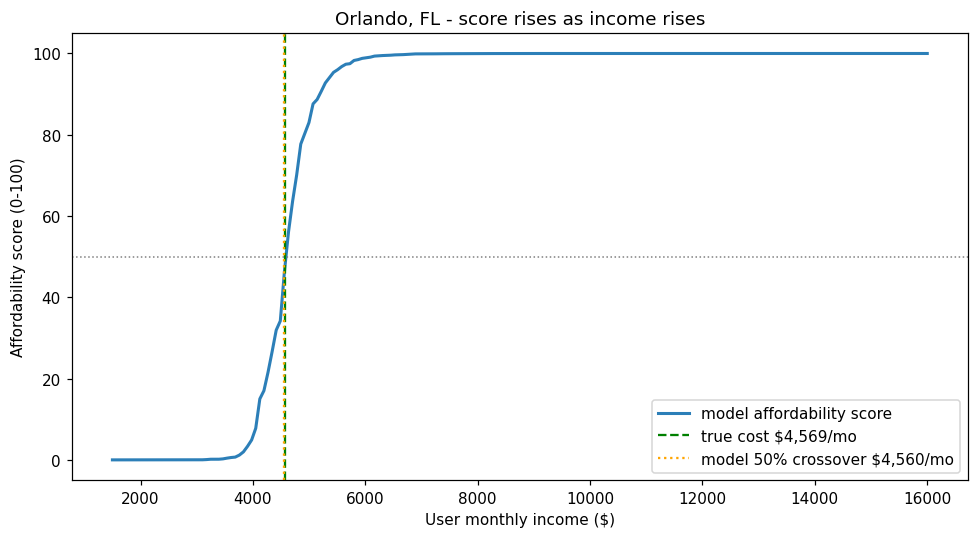

City: Orlando, FL | true cost $4,569/mo
Model crosses 50% affordable at $4,560/mo (should sit near the true cost).


In [6]:
demo_city = model_df.iloc[int(te[0])]
city_cost = float(demo_city[TARGET])

incomes = np.linspace(1500, 16000, 200)
grid = pd.DataFrame([demo_city[FEATURE_COLS].to_dict()] * len(incomes))
grid["user_income_monthly"] = incomes
sweep_prob = clf_income.predict_proba(grid[CLF_FEATURES])[:, 1] * 100
crossover = incomes[np.argmin(np.abs(sweep_prob - 50))]

plt.figure(figsize=(9, 5))
plt.plot(incomes, sweep_prob, color="#2c7fb8", linewidth=2, label="model affordability score")
plt.axvline(city_cost, color="green", linestyle="--", label=f"true cost ${city_cost:,.0f}/mo")
plt.axvline(crossover, color="orange", linestyle=":", label=f"model 50% crossover ${crossover:,.0f}/mo")
plt.axhline(50, color="gray", linestyle=":", linewidth=1)
plt.xlabel("User monthly income ($)")
plt.ylabel("Affordability score (0-100)")
plt.title(f"{demo_city['city'].title()}, {demo_city['state']} - score rises as income rises")
plt.legend()
plt.tight_layout()
plt.show()

print(f"City: {demo_city['city'].title()}, {demo_city['state']} | true cost ${city_cost:,.0f}/mo")
print(f"Model crosses 50% affordable at ${crossover:,.0f}/mo (should sit near the true cost).")

## 7. Assess function & save the model

In [7]:
def assess_city_income(feature_row, user_monthly_income):
    """Cost is predicted from city characteristics; affordability is judged by the
    income-aware classifier using the USER's income as an explicit feature."""
    base_row = pd.DataFrame([feature_row])[FEATURE_COLS].copy()
    predicted_cost = float(cost_model.predict(base_row)[0])

    clf_row = base_row.copy()
    clf_row["user_income_monthly"] = user_monthly_income
    score = round(float(clf_income.predict_proba(clf_row[CLF_FEATURES])[0, 1]) * 100, 1)

    verdict = "Affordable" if score >= 70 else "Stretched" if score >= 40 else "Unaffordable"
    return {
        "predicted_cost_of_living": round(predicted_cost, 2),
        "user_monthly_income": user_monthly_income,
        "monthly_surplus": round(user_monthly_income - predicted_cost, 2),
        "affordability_score": score,
        "verdict": verdict,
    }

joblib.dump(clf_income, "model_afford_income.pkl")
schema = {
    "clf_features": CLF_FEATURES,
    "income_feature": "user_income_monthly",
    "profile_encoding": PROFILE_ENCODING,
    "metrics": {"accuracy": round(float(acc_i), 4), "roc_auc": round(float(auc_i), 4)},
    "note": "Affordability classifier trained on cities replicated across many sampled incomes; "
            "user_income_monthly is an explicit feature, label = income >= real cost of living.",
}
with open("features_income.json", "w") as fobj:
    json.dump(schema, fobj, indent=2)
print("Saved model_afford_income.pkl and features_income.json\n")

features_row = demo_city[FEATURE_COLS].to_dict()
for inc in [3000, 5000, 8000, 12000]:
    out = assess_city_income(features_row, inc)
    print(f"Income ${inc:>6,}/mo -> cost ${out['predicted_cost_of_living']:>7,.0f} | "
          f"score {out['affordability_score']:>5} | {out['verdict']}")

Saved model_afford_income.pkl and features_income.json

Income $ 3,000/mo -> cost $  4,595 | score   0.0 | Unaffordable
Income $ 5,000/mo -> cost $  4,595 | score  83.0 | Affordable
Income $ 8,000/mo -> cost $  4,595 | score 100.0 | Affordable
Income $12,000/mo -> cost $  4,595 | score 100.0 | Affordable
